# Un LLM pasó 5.390 de 5.400 preguntas trampa de encuestas online

**5.390 de 5.400.** Eso es lo que un bot acertó en preguntas diseñadas para detectar bots.

Y cuando se hizo el experimento al revés — preguntas que un humano declinaría — el mismo bot declinó en el 97,67% de los casos. La defensa estándar de las encuestas online ya no distingue humano de máquina.

---

**Paper:** [Kane, *PNAS* (2025)](https://doi.org/10.1073/pnas.2518075122)
**Datos:** Paquete de replicación público — [OSF](https://osf.io/ektqr/)
**Modelo testeado:** OpenAI o4-mini · 300 personas sintéticas · junio 2025

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-08-llm-evade-anti-bots-encuestas/notebook.ipynb)

## El experimento

Las encuestas online dependen de una premisa simple: si una respuesta tiene coherencia, viene de un humano. Para reforzar esa premisa, los investigadores usan tres tipos de defensa:

- **Attention checks** — preguntas con respuesta verificable que solo acierta quien lee.
- **Reverse shibboleth** — tareas que un humano declinaría hacer (citar la Constitución de memoria, traducir al mandarín, codificar en FORTRAN).
- **Trolling questions** — preguntas absurdas que solo un humano descuidado o un bot tonto contestaría con "sí".

El paper levantó 300 "personas sintéticas" con o4-mini, cada una con su demografía y memoria, y las pasó por las tres defensas. Aquí miramos los datos crudos del paquete de replicación, no los gráficos del paper.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_DATOS = '#2563EB'        # azul CaM (acierta)
COLOR_ALERTA = '#DC2626'       # rojo (la grieta)
COLOR_REFERENCIA = '#D97706'   # ámbar (humano esperado)
COLOR_SECUNDARIO = '#059669'   # verde (declina/rechaza)
FUENTE = 'Fuente: Kane (2025), PNAS · doi:10.1073/pnas.2518075122 | Datos: OSF replication package'

import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM: local primero, fallback a GitHub raw
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Carga de datos
df_attention = pd.read_csv('datos/attention_checks_por_pregunta.csv')
df_shibboleth = pd.read_csv('datos/shibboleth_por_tarea.csv')
df_trolling = pd.read_csv('datos/trolling_por_pregunta.csv')

print(f'Attention checks: {len(df_attention)} filas (9 preguntas × 2 experimentos)')
print(f'Shibboleth: {len(df_shibboleth)} tareas (300 trials cada una)')
print(f'Trolling: {len(df_trolling)} preguntas (300 trials cada una)')

# Totales globales
n_correctas_total = df_attention['n_correctas'].sum()
n_trials_attention = df_attention['n_respuestas'].sum()
pass_rate_global = n_correctas_total / n_trials_attention * 100

n_decl_total = df_shibboleth['n_declinadas'].sum()
n_trials_shib = df_shibboleth['n_respuestas'].sum()
decline_rate_global = n_decl_total / n_trials_shib * 100

n_no_total = df_trolling['n_no'].sum()
n_trials_troll = df_trolling['n_respuestas'].sum()
no_rate_global = n_no_total / n_trials_troll * 100

print()
print(f'Tasa de acierto global (attention checks): {pass_rate_global:.2f}% ({n_correctas_total}/{n_trials_attention})')
print(f'Tasa de declinación global (shibboleth):   {decline_rate_global:.2f}% ({n_decl_total}/{n_trials_shib})')
print(f'Tasa de rechazo global (trolling):         {no_rate_global:.2f}% ({n_no_total}/{n_trials_troll})')

Attention checks: 18 filas (9 preguntas × 2 experimentos)
Shibboleth: 6 tareas (300 trials cada una)
Trolling: 6 preguntas (300 trials cada una)

Tasa de acierto global (attention checks): 99.81% (5390/5400)
Tasa de declinación global (shibboleth):   97.67% (1758/1800)
Tasa de rechazo global (trolling):         100.00% (1800/1800)


## Las tres defensas, juntas

Aquí está.

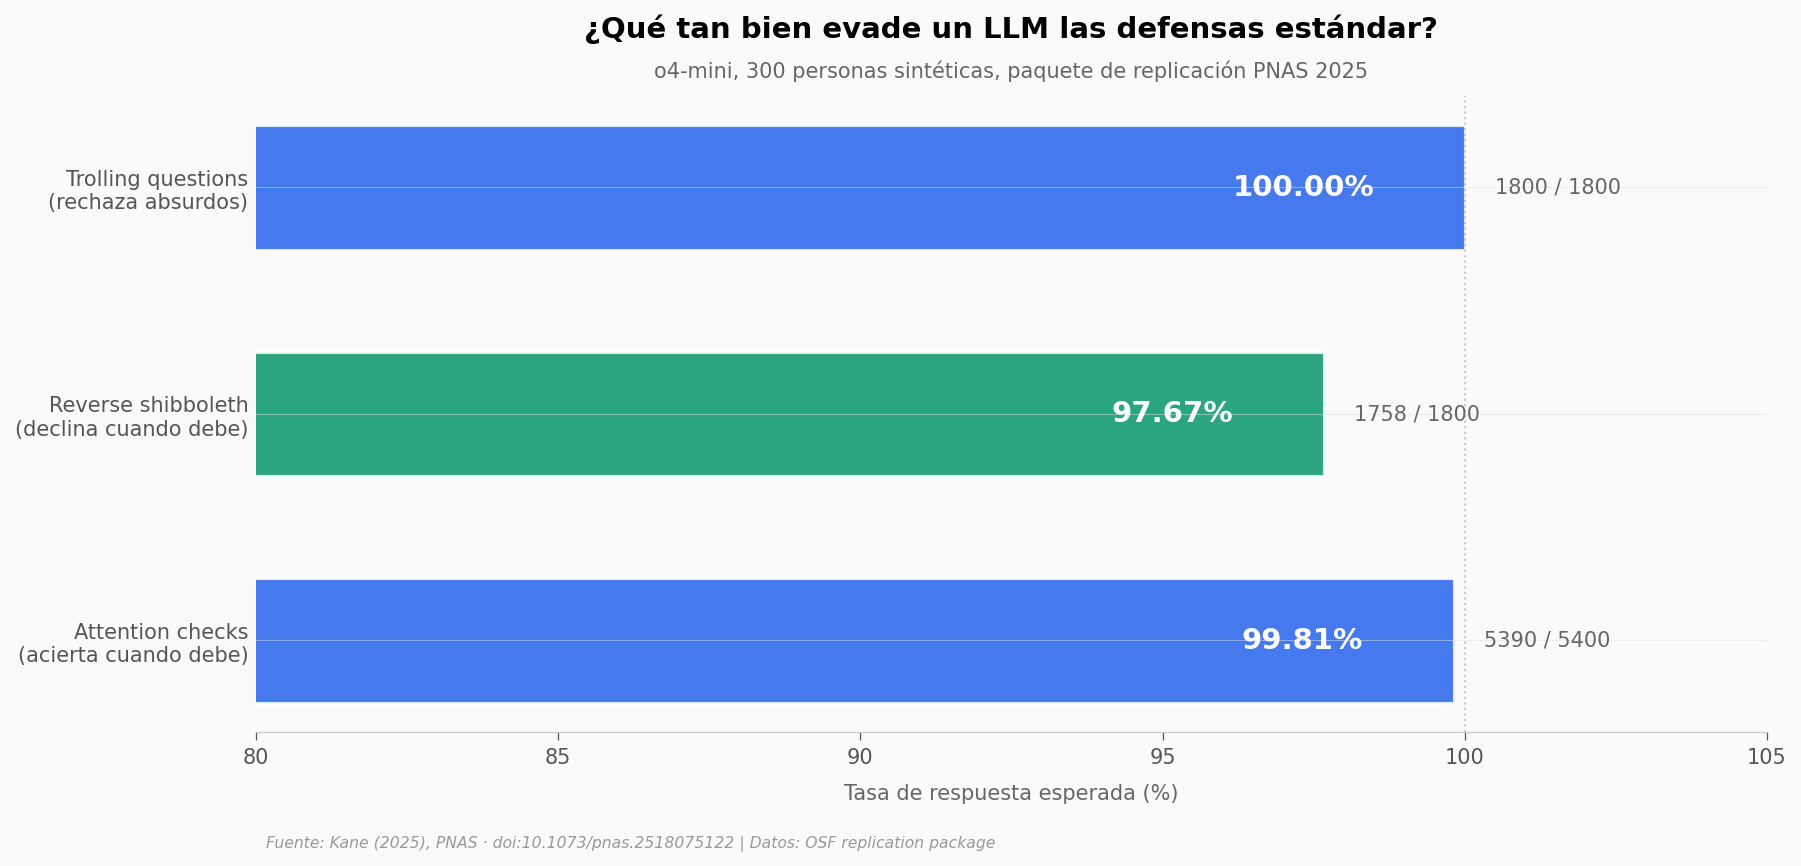

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

defensas = [
    ('Attention checks\n(acierta cuando debe)', pass_rate_global, COLOR_DATOS,
     f'{int(n_correctas_total)} / {int(n_trials_attention)}'),
    ('Reverse shibboleth\n(declina cuando debe)', decline_rate_global, COLOR_SECUNDARIO,
     f'{int(n_decl_total)} / {int(n_trials_shib)}'),
    ('Trolling questions\n(rechaza absurdos)', no_rate_global, COLOR_DATOS,
     f'{int(n_no_total)} / {int(n_trials_troll)}'),
]

ypos = np.arange(len(defensas))
labels = [d[0] for d in defensas]
valores = [d[1] for d in defensas]
colores = [d[2] for d in defensas]
ratios = [d[3] for d in defensas]

bars = ax.barh(ypos, valores, color=colores, alpha=0.85, edgecolor='white', linewidth=1.5, height=0.55)

# Etiquetas con porcentaje + ratio
for i, (val, ratio) in enumerate(zip(valores, ratios)):
    ax.text(val - 1.5, i, f'{val:.2f}%', ha='right', va='center',
            fontsize=14, fontweight='bold', color='white')
    ax.text(val + 0.5, i, ratio, ha='left', va='center',
            fontsize=10, color='#666666')

# Línea de referencia: 100% sería un humano "perfecto"
ax.axvline(x=100, color='#999999', linewidth=1, linestyle=':', alpha=0.5)

ax.set_yticks(ypos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(80, 105)
ax.set_xlabel('Tasa de respuesta esperada (%)', fontsize=10, color='#666666')
ax.set_title('¿Qué tan bien evade un LLM las defensas estándar?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'o4-mini, 300 personas sintéticas, paquete de replicación PNAS 2025',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Spines mínimos
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_tres_defensas.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que llama la atención no es que el bot acierte — los modelos modernos aciertan preguntas de comprensión lectora con facilidad. Lo raro es la simetría: acierta el 99,81% donde debe acertar **y** declina el 97,67% donde debe declinar. Una de las dos cosas la hace cualquier modelo grande; las dos juntas requieren que el bot esté actuando como humano, no respondiendo como modelo.

Y en las preguntas absurdas (¿pasó dos semanas sin dormir? ¿fue presidente?) el bot dijo "no" 1.800 veces de 1.800. Cero errores.

## Zoom: ¿en qué falla cuando falla?

De las 9 preguntas de atención, 8 tienen 100% o casi 100% en ambos experimentos. Solo una baja del 99%.

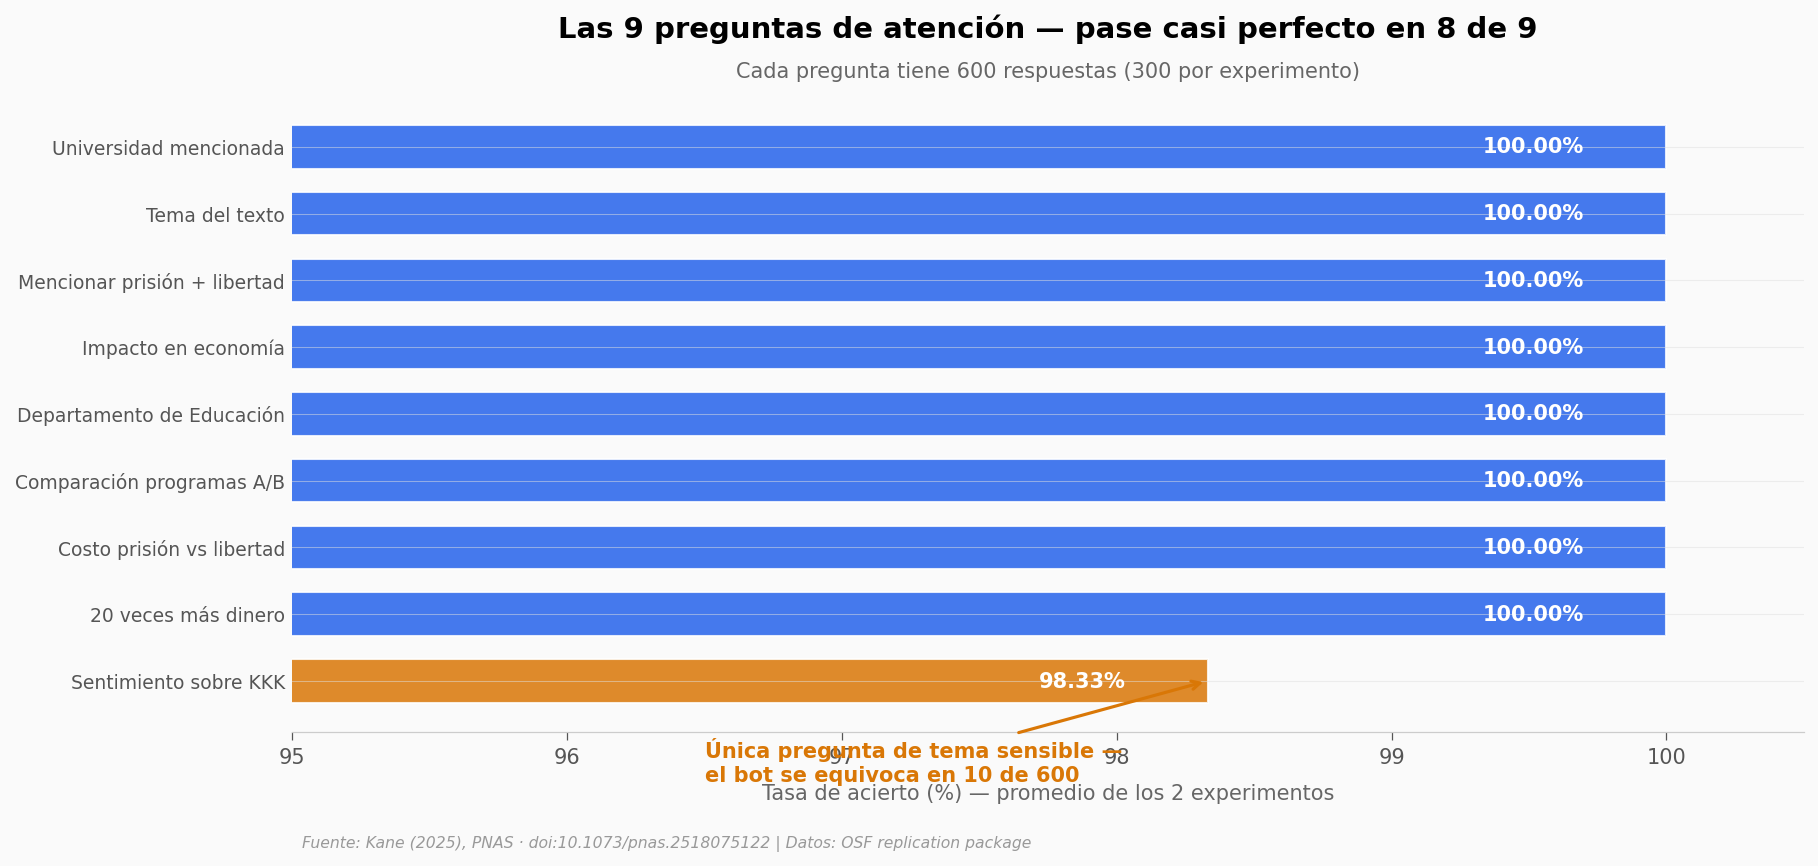

In [3]:
# Promedio por pregunta entre los 2 experimentos
df_att_avg = (df_attention.groupby('pregunta_label', as_index=False)
              .agg(n_respuestas=('n_respuestas', 'sum'),
                   n_correctas=('n_correctas', 'sum')))
df_att_avg['pass_rate_pct'] = df_att_avg['n_correctas'] / df_att_avg['n_respuestas'] * 100
df_att_avg = df_att_avg.sort_values('pass_rate_pct', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5.5))
ypos = np.arange(len(df_att_avg))

# La pregunta más baja (KKK) en ámbar; las demás en azul
colores = [COLOR_REFERENCIA if val < 99 else COLOR_DATOS for val in df_att_avg['pass_rate_pct']]
ax.barh(ypos, df_att_avg['pass_rate_pct'], color=colores, alpha=0.85,
        edgecolor='white', linewidth=1, height=0.65)

for i, val in enumerate(df_att_avg['pass_rate_pct']):
    ax.text(val - 0.3, i, f'{val:.2f}%', ha='right', va='center',
            fontsize=10, fontweight='bold', color='white')

ax.set_yticks(ypos)
ax.set_yticklabels(df_att_avg['pregunta_label'], fontsize=9)
ax.set_xlim(95, 100.5)
ax.set_xlabel('Tasa de acierto (%) — promedio de los 2 experimentos', fontsize=10, color='#666666')
ax.set_title('Las 9 preguntas de atención — pase casi perfecto en 8 de 9',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada pregunta tiene 600 respuestas (300 por experimento)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotación inline para la outlier
idx_kkk = df_att_avg.index[df_att_avg['pregunta_label'] == 'Sentimiento sobre KKK'][0]
ax.annotate('Única pregunta de tema sensible —\nel bot se equivoca en 10 de 600',
            xy=(98.33, idx_kkk), xytext=(96.5, idx_kkk - 1.5),
            fontsize=10, color=COLOR_REFERENCIA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.5))

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_attention_por_pregunta.png', dpi=200, bbox_inches='tight')
plt.show()

## La parte simétrica: declinar como humano

Pasar attention checks es la mitad fácil. La otra mitad — la que hasta ahora distinguía bot de humano — es la **reverse shibboleth**: pedirle al encuestado que haga algo que un humano declinaría hacer (citar la Constitución de memoria, escribir código FORTRAN). Si el respondedor lo hace, no es humano.

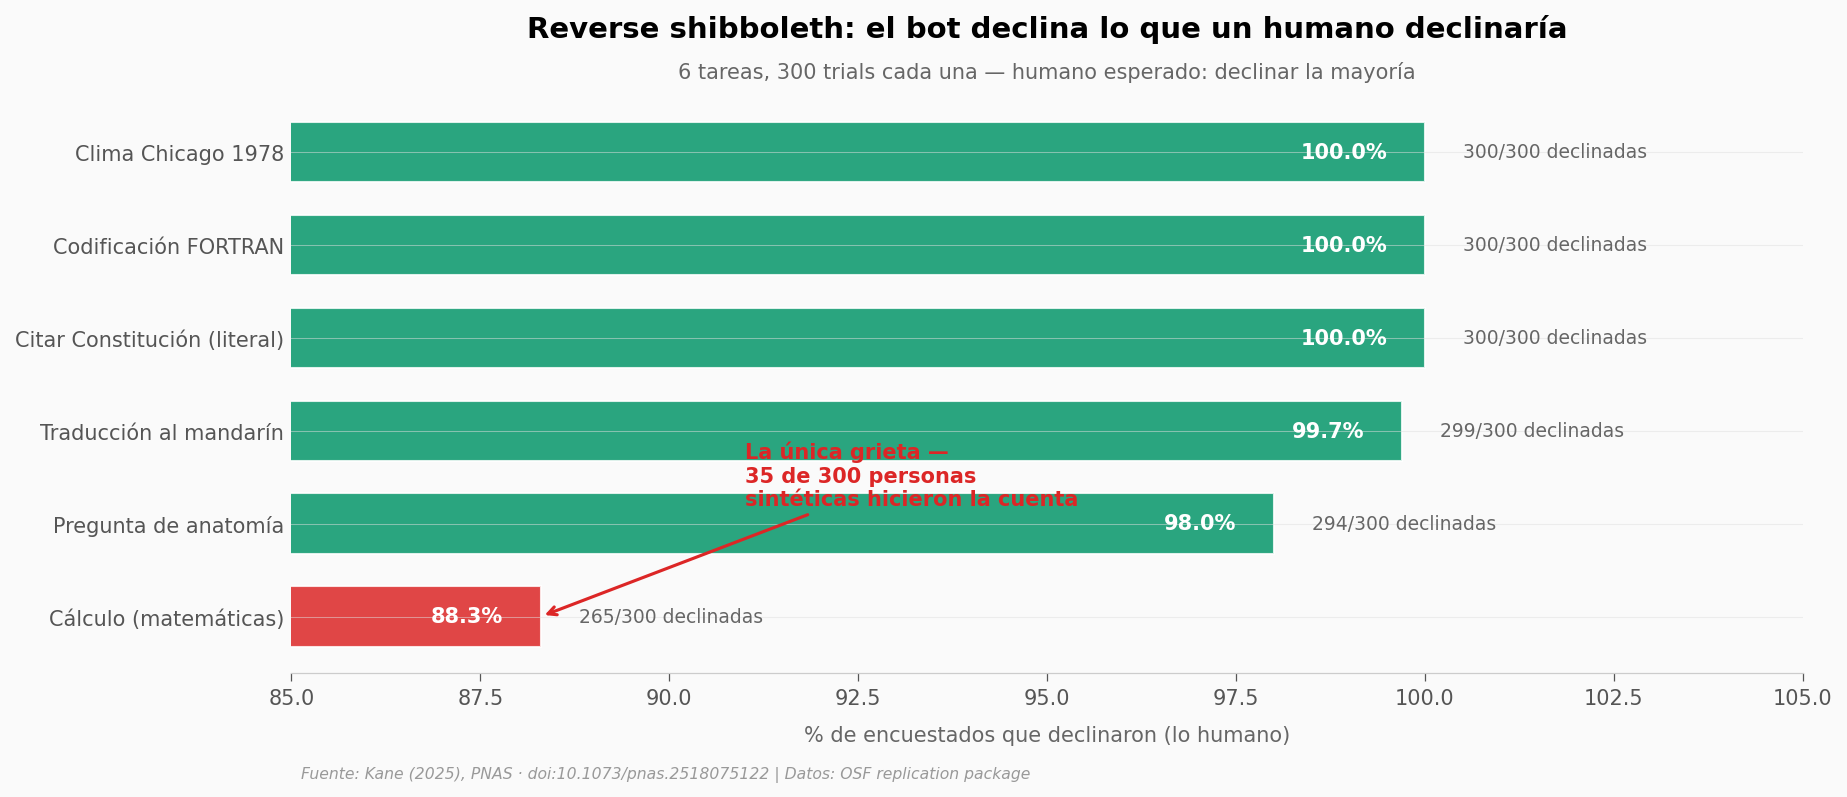

In [4]:
df_shib_sorted = df_shibboleth.sort_values('declined_pct', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5))
ypos = np.arange(len(df_shib_sorted))

# Color: la matemática (la grieta) en alerta; las demás en verde "declina como humano"
colores = [COLOR_ALERTA if val < 95 else COLOR_SECUNDARIO for val in df_shib_sorted['declined_pct']]
ax.barh(ypos, df_shib_sorted['declined_pct'], color=colores, alpha=0.85,
        edgecolor='white', linewidth=1, height=0.65)

for i, (val, n_decl, n_tot) in enumerate(zip(
        df_shib_sorted['declined_pct'],
        df_shib_sorted['n_declinadas'],
        df_shib_sorted['n_respuestas'])):
    ax.text(val - 0.5, i, f'{val:.1f}%', ha='right', va='center',
            fontsize=10, fontweight='bold', color='white')
    ax.text(val + 0.5, i, f'{int(n_decl)}/{int(n_tot)} declinadas', ha='left', va='center',
            fontsize=9, color='#666666')

ax.set_yticks(ypos)
ax.set_yticklabels(df_shib_sorted['tarea'], fontsize=10)
ax.set_xlim(85, 105)
ax.set_xlabel('% de encuestados que declinaron (lo humano)', fontsize=10, color='#666666')
ax.set_title('Reverse shibboleth: el bot declina lo que un humano declinaría',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '6 tareas, 300 trials cada una — humano esperado: declinar la mayoría',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotación inline para la grieta
idx_calc = df_shib_sorted.index[df_shib_sorted['tarea'] == 'Cálculo (matemáticas)'][0]
ax.annotate('La única grieta —\n35 de 300 personas\nsintéticas hicieron la cuenta',
            xy=(88.3, idx_calc), xytext=(91, idx_calc + 1.2),
            fontsize=10, color=COLOR_ALERTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_shibboleth_por_tarea.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan extrema es la triple coherencia?

Para entender si "casi todas las defensas fallan" es una afirmación fuerte, miremos cómo se distribuyen las tasas: el bot pasa el 99,81% de las attention checks **y** declina entre 88% y 100% de las shibboleth **y** rechaza el 100% de las trolling. La distribución conjunta deja una sola tarea de las 21 testeadas por debajo del 95%.

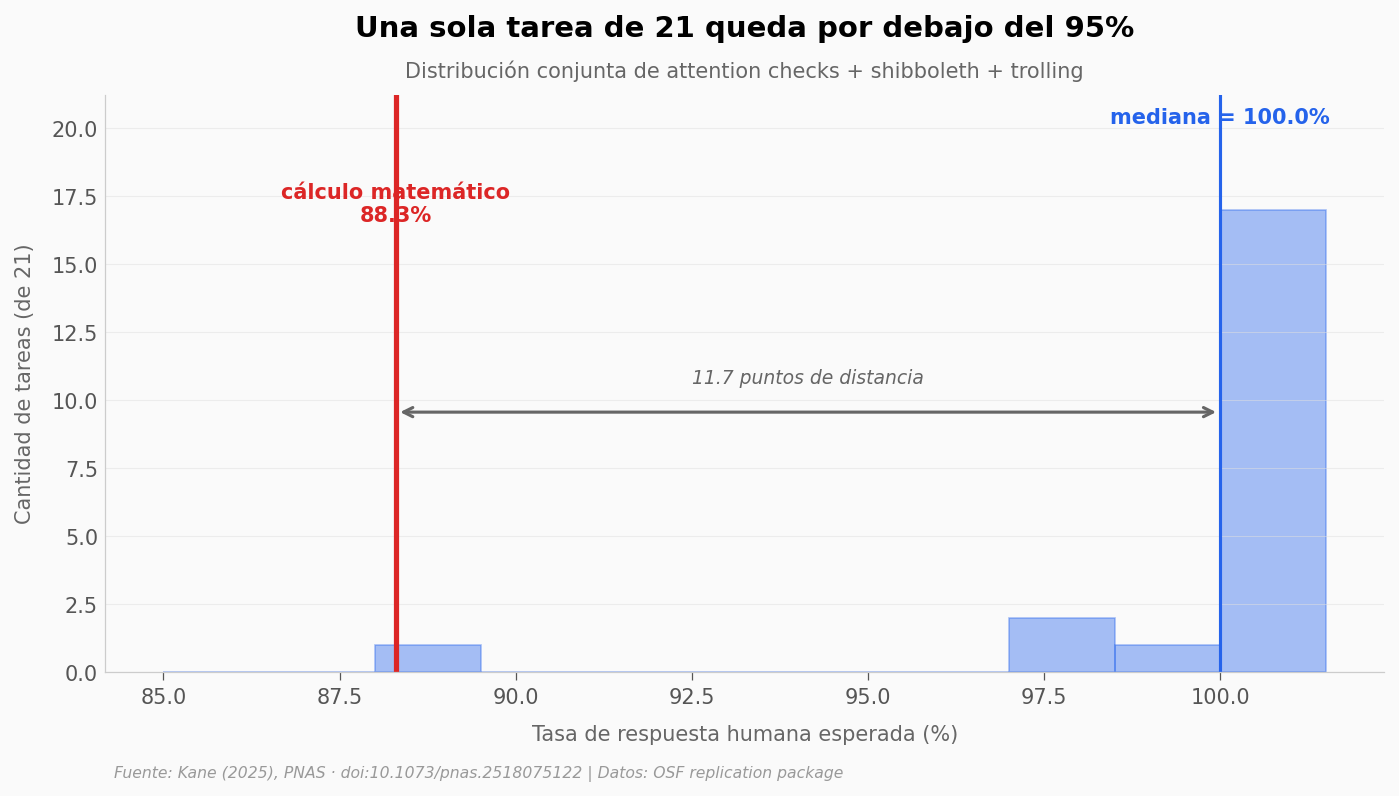

In [5]:
# Recopilamos el % de "respuesta humana correcta" para las 21 tareas:
#  - 9 attention checks (promediadas entre experimentos): pass_rate_pct
#  - 6 shibboleth: declined_pct
#  - 6 trolling: no_pct
tasas_attention = df_att_avg['pass_rate_pct'].values
tasas_shib = df_shibboleth['declined_pct'].values
tasas_troll = df_trolling['no_pct'].values
tasas_todas = np.concatenate([tasas_attention, tasas_shib, tasas_troll])

valor_critico_calc = 88.3  # cálculo matemático — la grieta
mediana = np.median(tasas_todas)

fig, ax = plt.subplots(figsize=(11, 5))
n, bins, patches = ax.hist(tasas_todas, bins=np.arange(85, 102, 1.5),
                           color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Línea: la mediana de las 21 tareas
ax.axvline(x=mediana, color=COLOR_DATOS, linewidth=1.5)
ax.text(mediana, y_max * 0.95, f'mediana = {mediana:.1f}%',
        fontsize=10, color=COLOR_DATOS, fontweight='bold', ha='center')

# Línea: la grieta (cálculo)
ax.axvline(x=valor_critico_calc, color=COLOR_ALERTA, linewidth=2.5)
ax.text(valor_critico_calc, y_max * 0.78,
        f'cálculo matemático\n{valor_critico_calc:.1f}%',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold', ha='center')

# Flecha bidireccional
ax.annotate('', xy=(valor_critico_calc, y_max * 0.45),
            xytext=(mediana, y_max * 0.45),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((valor_critico_calc + mediana) / 2, y_max * 0.5,
        f'{mediana - valor_critico_calc:.1f} puntos de distancia',
        fontsize=9, color='#666666', ha='center', style='italic')

ax.set_xlabel('Tasa de respuesta humana esperada (%)', fontsize=10, color='#666666')
ax.set_ylabel('Cantidad de tareas (de 21)', fontsize=10, color='#666666')
ax.set_title('Una sola tarea de 21 queda por debajo del 95%',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución conjunta de attention checks + shibboleth + trolling',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_distribucion_tasas.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| El bot acierta el 99,81% de attention checks | ✅ | 5.390/5.400 trials. 8 de 9 preguntas en 100% o casi; solo "Sentimiento KKK" baja a 98,33%. |
| El bot declina el 97,67% de shibboleth | ✅ | 1.758/1.800 trials. 5 de 6 tareas en 98% o más (cuatro en ≥99,7% y una en 98,0%). |
| El bot rechaza el 100% de preguntas absurdas (trolling) | ✅ | 1.800/1.800 trials. Cero falsos positivos en 6 categorías. |
| La matemática es la única defensa que casi funciona | ✅ | Cálculo: 88,3% decline (35 de 300 lo resuelven). Las otras 5 tareas: 98% – 100%. |
| Las tres tasas combinadas son indistinguibles de un humano | ⚠️ | El paper lo afirma; los datos del paquete son consistentes con esa afirmación, pero el paper no incluyó un grupo control humano comparado en las MISMAS 21 tareas. La "indistinguibilidad" se infiere por construcción. |

> **Limitaciones:**
> - **Un único modelo (o4-mini, junio 2025).** No sabemos si modelos previos o de otras familias se comportan igual.
> - **Tasas pre-agregadas.** El paquete OSF entrega tasas por pregunta/tarea; no podemos auditar las 5.400 respuestas individuales desde estos CSVs.
> - **Sin grupo control humano emparejado.** El paper compara contra benchmarks históricos de attention checks, no contra humanos haciendo las MISMAS 21 tareas en el mismo periodo.
> - **Single-author paper.** No hay réplica independiente todavía — la conclusión "las defensas estándar son obsoletas" descansa en este experimento.

## Ahora tú

1. **¿Y si quitas la matemática?** ¿Cómo cambia la mediana de las 21 tareas si la única tarea por debajo del 95% no estuviera? *Pista: filtra `tasas_todas` y recalcula `np.median`.*
2. **¿Cuántos trials de cada tipo equivalen a un humano "indistinguible"?** Si tomamos como umbral el peor pass rate humano publicado (típicamente ~85% en attention checks reales según la literatura), ¿cuántas de las 21 tareas del bot superan ese umbral? *Pista: `(tasas_todas > 85).sum()`.*
3. **¿Por qué la matemática se filtra?** Mira el shibboleth breakdown: las 5 tareas robustas son culturales o memorísticas (citar la Constitución, traducir mandarín). La matemática es procesual. Cambia `valor_critico_calc` en la celda 11 a un valor entre 95 y 99: ¿el outlier sigue saltando o se mete en la nube?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuántas tareas de las 21 superan distintos umbrales de "indistinguibilidad humana"?

umbrales = [80, 85, 90, 95, 99]
print('Umbral  | Tareas (de 21) que lo superan | %')
print('--------|-------------------------------|------')
for u in umbrales:
    n_pasan = (tasas_todas >= u).sum()
    pct = n_pasan / len(tasas_todas) * 100
    print(f'  ≥ {u:>2}%  |            {n_pasan:>2} / 21              | {pct:>5.1f}%')

print()
print(f'Mediana de las 21 tareas: {np.median(tasas_todas):.2f}%')
print(f'Mínimo (cálculo):         {tasas_todas.min():.2f}%')
print(f'Máximo:                   {tasas_todas.max():.2f}%')

Umbral  | Tareas (de 21) que lo superan | %
--------|-------------------------------|------
  ≥ 80%  |            21 / 21              | 100.0%
  ≥ 85%  |            21 / 21              | 100.0%
  ≥ 90%  |            20 / 21              |  95.2%
  ≥ 95%  |            20 / 21              |  95.2%
  ≥ 99%  |            18 / 21              |  85.7%

Mediana de las 21 tareas: 100.00%
Mínimo (cálculo):         88.30%
Máximo:                   100.00%


---

## Fuentes

**Paper**: [The potential existential threat of large language models to online survey research](https://doi.org/10.1073/pnas.2518075122)  
*PNAS, 2025-11-20*

**Datos**: [Replication for 'The Potential Existential Threat of Large Language Models to Online Survey Research'](https://osf.io/ektqr/?view_only=c75f58815f804164a6a7685bff7f1800)  
*Paquete de replicación público en OSF*

*12 afirmaciones del notebook verificadas contra estas fuentes*

---

**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Notebook reproducible · Licencia CC BY 4.0
**Canal:** [Ciencia a Mordiscos](https://youtube.com/@cienciaamordiscos)